In [1]:
from functools import partial
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.processing import make_future_dataframe


import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsmodels.tsa.seasonal import seasonal_decompose

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from coreforecast.scalers import boxcox, boxcox_lambda
from utilsforecast.losses import rmse, mae, smape
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from statsforecast.models import AutoETS
from statsforecast.arima import ndiffs, nsdiffs
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA
from statsforecast.arima import ARIMASummary
from copy import deepcopy

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown, Image

from fpppy.utils import plot_series

# endregion 
from plotnine import *

# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2



# Chapter 10: Dynamic regression models

PlotnineError: "Could not evaluate the 'y' mapping: 'Consumption' (original error: name 'Consumption' is not defined)"

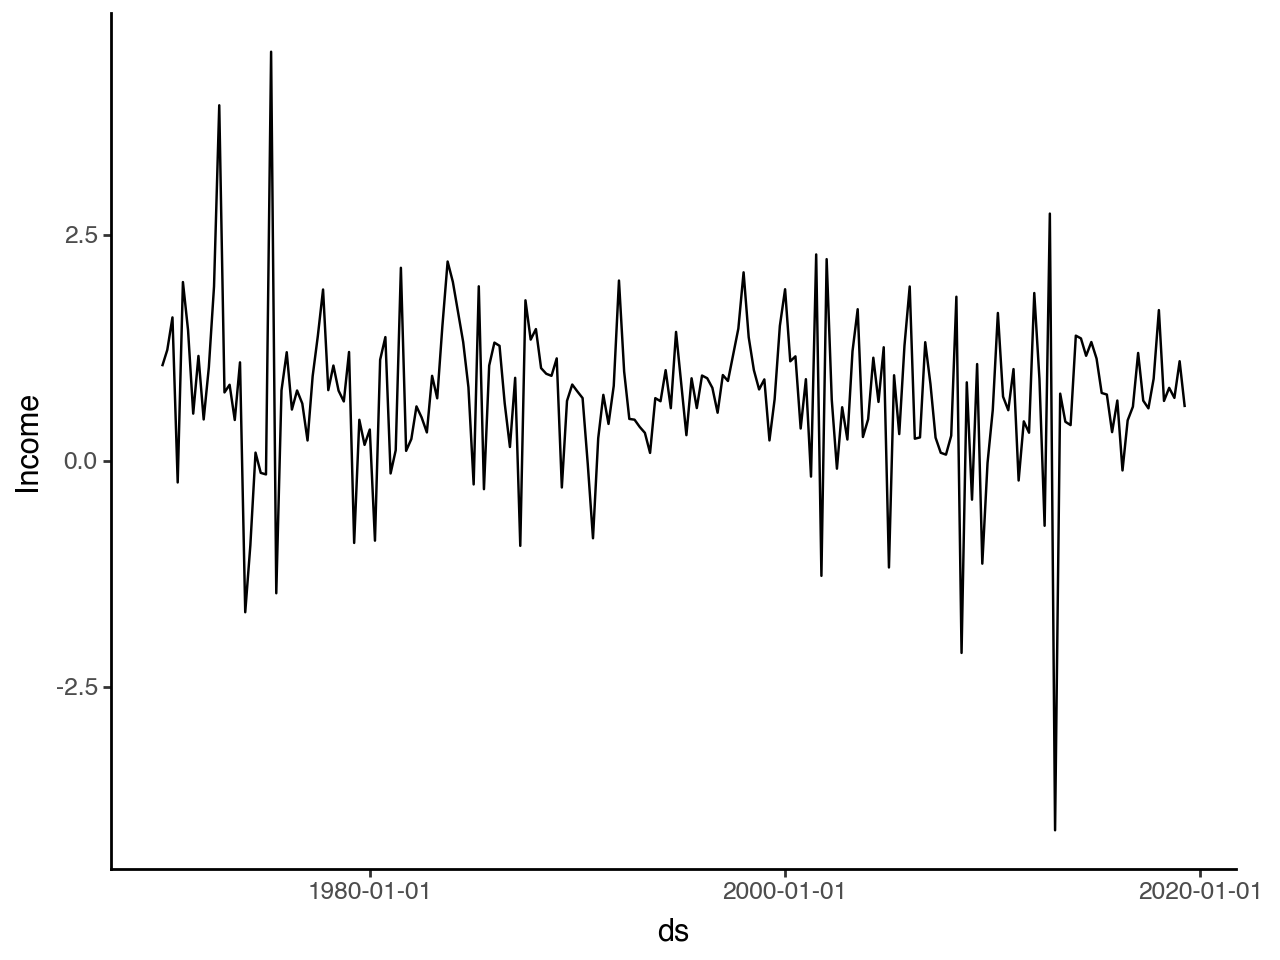

In [14]:
# Example: US personal consumption and income 
df_cons = pd.read_csv('data/raw/US_change.csv', parse_dates=['ds'])
df_cons.rename(columns={"Consumption": "y"}, inplace=True)

# plot consumption and income 
(ggplot(data=df_cons, mapping=aes(x='ds', y='Consumption')) + 
    geom_line() +
    theme_classic())

(ggplot(data=df_cons, mapping=aes(x='ds', y='Income')) + 
    geom_line() +
    theme_classic())

In [16]:
# examine whether differncing is required
print("Recommended differencing order:", ndiffs(x=df_cons['y'].values))
print("Recommended differencing order:", ndiffs(x=df_cons['Income'].values))
df_cons.head()

Recommended differencing order: 0
Recommended differencing order: 0


,ds,y,Income,Production,Savings,Unemployment,unique_id
0,1970-01-01,0.618566,1.044801,-2.452486,5.299014,0.9,US_change
1,1970-04-01,0.451984,1.225647,-0.551459,7.789894,0.5,US_change
2,1970-07-01,0.872872,1.585154,-0.358652,7.403984,0.5,US_change
3,1970-10-01,-0.271848,-0.239545,-2.185691,1.169898,0.7,US_change
4,1971-01-01,1.901345,1.975925,1.909764,3.535667,-0.1,US_change


In [25]:
# examine best-fitting ARIMA model (with and wiwhout predictors)
model = [ARIMA(order=(1,0,2), season_length=4, alias="arima201")]
sf = StatsForecast(models=model, freq="QE", n_jobs=-1)

sf.fit(df_cons[['unique_id', "y", "ds", "Income"]], target_col='y')




StatsForecast(models=[arima201])

In [26]:
print(ARIMASummary(sf.fitted_[0, 0].model_))
coefs = deepcopy(sf.fitted_[0, 0].model_['coef'])
coefs["mean"] = coefs.pop("intercept")
print(f"Coefficients: {coefs}")
print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")


Regression with ARIMA(1,0,2) errors
Coefficients: {'ar1': 0.7070114851218271, 'ma1': -0.6172229737938505, 'ma2': 0.20663433860131597, 'ex_1': 0.19762557486462035, 'mean': 0.5949262308799619}
sigma^2     : 0.31
loglik      : -163.04
aic         : 338.07
aicc        : 338.51
bic         : 357.80


ARIMA(1,0,2) model above results in following equation: 

$$
\begin{aligned}
y_t &= 0.59 + 0.20 x_t + \eta_y \\ 
\eta_t &= .71
\end{aligned}
$$

1666.6666666666667